In [27]:
pip install -U pydantic

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.7 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.27.2
    Not uninstalling pydantic-core at /opt/conda/lib/python3.11/site-packages, outside environment /root/.clearml/venvs-builds/3.11
    Can't uninstall 'pydantic_core'. No files were found to uninstall.
  Attempting uninstall: pydantic
    Found existing installation: pydantic 1.10.22
    Uninstalling pydantic-1.10.22:
      Successfully uninstalled pydantic-1.10.22
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastapi 0.89.1 requires pydantic!=1.7,!=1.7.1,!=1.7.2,!=1.7.3,!=1.8,!=1.8.1,<2.0.0,>=1.6.2, but you have pydantic 2.11.7 which is incompatible.
mistral-common 1.5.3 requires numpy>=1.25; python_version >= "3.9", but you have numpy 1.23.5 which is incompatible.
vllm 0.6.6 requires fastap

In [1]:
import json
import torch
import numpy as np

In [2]:
from deeppavlov import build_model, train_model, train_evaluate_model_from_config, evaluate_model
from deeppavlov.core.common.file import read_json

In [3]:
from deeppavlov.dataset_readers.hallucination_detection_reader import HallucinationDatasetReader, RAGTruthDatasetReader

In [4]:
from transformers import AutoModel, AutoConfig, AutoTokenizer, AutoModelForTokenClassification

In [5]:
from deeppavlov.core.data.data_learning_iterator import DataLearningIterator
from deeppavlov.models.preprocessors.torch_transformers_preprocessor import TorchTransformersHallucinationDetectorPreprocessor 
from deeppavlov.metrics.fmeasure import token_binary_f1, token_binary_precision, token_binary_recall

2025-07-02 16:07:28.10 WARNING in 'deeppavlov.core.common.registry'['registry'] at line 56: Registry name "torch_transformers_hallucination_detector_postprocessor" has been already registered and will be overwritten.


In [6]:
from tqdm import tqdm

In [7]:
device = 'cuda'

In [8]:
path = 'deeppavlov/configs/hallucination_detection/ragtruth_mdeberta_base.json'
# path = 'deeppavlov/configs/hallucination_detection/ragtruth_modernbert_base.json'
# path = 'deeppavlov/configs/hallucination_detection/ragtruth_modernbert_large.json'
# path = 'deeppavlov/configs/hallucination_detection/ragtruth_mbert_base.json'
# path = 'deeppavlov/configs/hallucination_detection/ragtruth_deberta_small.json'


# path = 'deeppavlov/configs/hallucination_detection/ragtruth_eurobert_base.json'

In [9]:
config = read_json(path)

In [12]:
model = build_model(config, load_trained=True)

/root/.clearml/venvs-builds/3.11/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fde3177ffd0>>
Traceback (most recent call last):
  File "/root/.clearml/venvs-builds/3.11/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 

KeyboardInterrupt



In [11]:
main_model = model.get_main_component().model

In [12]:
main_model.to(device)
main_model.eval()
print()

In [13]:
# evaluate_model(config)

In [10]:
ds = RAGTruthDatasetReader().read("/root/.deeppavlov/downloads/ragtruth/", validation_split=0.10)

2025-07-02 16:07:28.31 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 53: Preprocessing raw RAGTruth data...
2025-07-02 16:07:28.32 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 177: Loading raw data from /root/.deeppavlov/downloads/ragtruth/response.jsonl and /root/.deeppavlov/downloads/ragtruth/source_info.jsonl
2025-07-02 16:07:28.253 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 229: Loaded 17790 responses and 2965 sources
2025-07-02 16:07:28.495 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 203: Preprocessed 17790 samples from raw data
2025-07-02 16:07:29.257 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 269: Saved preprocessed data to /root/.deeppavlov/downloads/ragt

loading cn version!


2025-07-02 16:07:32.953 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 140: Skipped 1511 samples with empty prompt or answer or validation.


loading fr version!


2025-07-02 16:07:35.809 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 140: Skipped 1509 samples with empty prompt or answer or validation.


...

2025-07-02 16:07:45.667 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 140: Skipped 1510 samples with empty prompt or answer or validation.


loading de version!


2025-07-02 16:07:49.10 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 140: Skipped 1508 samples with empty prompt or answer or validation.


loading pl version!


2025-07-02 16:07:52.59 INFO in 'deeppavlov.dataset_readers.hallucination_detection_reader'['hallucination_detection_reader'] at line 140: Skipped 1509 samples with empty prompt or answer or validation.


In [11]:
iterator = DataLearningIterator(ds)

In [16]:
tokenizer = AutoTokenizer.from_pretrained(config['metadata']['variables']['TRANSFORMER'])
do_lower_case = config['chainer']['pipe'][0]['do_lower_case']
# max_seq_length = config['chainer']['pipe'][0]['max_seq_length']
max_seq_length = 4096

In [37]:
# # xs = []
# skipped = 0
# for batch in tqdm(iterator.gen_batches(1, data_type='train'), total=len(ds['train'])):
#     x, y = batch
#     prompt = x[0]['prompt']
#     answer = x[0]['answer']
#     language =  x[0]['language']
#     if language == 'chinese':
#         if prompt.startswith("指令：\n仅根据提供的 JSON") and answer.startswith("Taco Tuyo 是一家位于加利"): # broken example
#             skipped += 1
#             print('ch')
#             continue
#     if language == 'hungarian':
#         if prompt.startswith("Foglalja össze") and answer.startswith("Taylor Swift popénekesnő"):
#             skipped += 1
#             print('hg')
#             continue
#     # try:
#     #     encoding, _, offsets, answer_start_token = TorchTransformersHallucinationDetectorPreprocessor.prepare_tokenized_input(
#     #             tokenizer, prompt, answer, max_seq_length
#     #         )
#     # except:
#     #     xs.append(x)
#     #     print('problem')

 55%|█████▍    | 64972/118993 [00:00<00:00, 334996.18it/s]

ch
hg


100%|██████████| 118993/118993 [00:00<00:00, 335510.37it/s]


In [18]:
gt_spans = []
pred_spans = []
task_types = []
languages = []

for batch in tqdm(iterator.gen_batches(1, data_type='test'), total=len(ds['test'])):
    x, y = batch
    prompt = x[0]['prompt']
    answer = x[0]['answer']
    task_types.append(x[0]['task_type'])
    gt_spans.append(x[0]['labels'])
    languages.append(x[0]['language'])

    encoding, _, offsets, answer_start_token = TorchTransformersHallucinationDetectorPreprocessor.prepare_tokenized_input(
            tokenizer, prompt, answer, max_seq_length
        )
    labels = torch.full_like(encoding.input_ids[0], -100, device=device)
    labels[answer_start_token:] = 0
    encoding = {
            key: value.to(device)
            for key, value in encoding.items()
            if key in ["input_ids", "attention_mask", "labels"]
        }
    with torch.inference_mode():
        outputs = main_model(**encoding)
    logits = outputs.logits
    token_preds = torch.argmax(logits, dim=-1)[0]
    probabilities = torch.softmax(logits, dim=-1)[0]
    token_preds = torch.where(labels == -100, labels, token_preds)

    if answer_start_token < offsets.size(0):
        answer_char_offset = offsets[answer_start_token][0].item()
    else:
        answer_char_offset = 0

    spans: list[dict] = []
    current_span: dict | None = None

    for i in range(answer_start_token, token_preds.size(0)):
        # Skip tokens marked as ignored.
        if labels[i].item() == -100:
            continue

        token_start, token_end = offsets[i].tolist()
        # Skip special tokens with zero length.
        if token_start == token_end:
            continue

        # Adjust offsets relative to the answer text.
        rel_start = token_start - answer_char_offset
        rel_end = token_end - answer_char_offset

        is_hallucination = (
            token_preds[i].item() == 1
        )  # assuming class 1 indicates hallucination.
        confidence = probabilities[i, 1].item() if is_hallucination else 0.0

        if is_hallucination:
            if current_span is None:
                current_span = {
                    "start": rel_start,
                    "end": rel_end,
                    "confidence": confidence,
                }
            else:
                # Extend the current span.
                current_span["end"] = rel_end
                current_span["confidence"] = max(current_span["confidence"], confidence)
        else:
            # If we were building a hallucination span, finalize it.
            if current_span is not None:
                # Extract the hallucinated text from the answer.
                span_text = answer[current_span["start"] : current_span["end"]]
                current_span["text"] = span_text
                spans.append(current_span)
                current_span = None

    # Append any span still in progress.
    if current_span is not None:
        span_text = answer[current_span["start"] : current_span["end"]]
        current_span["text"] = span_text
        spans.append(current_span)
    pred_spans.append(spans)


100%|██████████| 21600/21600 [18:12<00:00, 19.77it/s]


In [11]:
import pandas as pd

In [13]:
df = pd.DataFrame({
    "task_type": task_types,
    "pred_spans": pred_spans,
    "gt_spans": gt_spans,
    "language": languages,
})

In [37]:
# df.to_json('mdeberta_pred.json')

In [12]:
from sklearn.metrics import precision_recall_fscore_support, classification_report, roc_curve, auc

def calc_span_level_metrics(gt_spans, pred_spans):
    total_overlap = 0
    total_predicted = 0
    total_gold = 0
    for gold_spans, predicted_spans in zip(gt_spans, pred_spans):
        sample_predicted_length = sum(pred["end"] - pred["start"] for pred in predicted_spans)
        total_predicted += sample_predicted_length
    
        # Compute total gold span length once for this sample.
        sample_gold_length = sum(gold["end"] - gold["start"] for gold in gold_spans)
        total_gold += sample_gold_length
    
        # Now, compute the overlap between each predicted span and each gold span.
        sample_overlap = 0
        for pred in predicted_spans:
            for gold in gold_spans:
                overlap_start = max(pred["start"], gold["start"])
                overlap_end = min(pred["end"], gold["end"])
                if overlap_end > overlap_start:
                    sample_overlap += overlap_end - overlap_start
        total_overlap += sample_overlap
    
    precision = total_overlap / total_predicted if total_predicted > 0 else 0
    recall = total_overlap / total_gold if total_gold > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    span_results = {"precision": round(precision, 4), "recall": round(recall, 4), "f1": round(f1, 4)}


    example_labels = [1 if len(gold) > 0 else 0 for gold in gt_spans]
    example_preds = [1 if len(pred) > 0 else 0 for pred in pred_spans]

    precision, recall, f1, _ = precision_recall_fscore_support(
        example_labels, example_preds, labels=[0, 1], average=None, zero_division=0
    )
    example_level_results = {
        "precision": round(float(precision[1]), 4),
        "recall": round(float(recall[1]), 4),
        "f1": round(float(f1[1]), 4),
    }

    results = {
        "span_level": span_results,
        "example_level": example_level_results,
    }

    return results

In [44]:
for lang, subdf in df.groupby('language'):
    print(lang)
    print(calc_span_level_metrics(subdf.gt_spans.values, subdf.pred_spans.values)['span_level']['f1'])


chinese
0.5425
en
0.559
french
0.5497
german
0.5372
hungarian
0.5233
italian
0.5424
polish
0.5385
spanish
0.5517


In [50]:
for task_type, subdf in eng_df.groupby('task_type'):
    print(task_type)
    
    print(calc_span_level_metrics(subdf.gt_spans.values, subdf.pred_spans.values))

print('overall')
print(calc_span_level_metrics(eng_df.gt_spans.values, eng_df.pred_spans.values))


Data2txt
{'precision': 0.6183, 'recall': 0.5963, 'f1': 0.6071}
QA
{'precision': 0.6196, 'recall': 0.5904, 'f1': 0.6047}
Summary
{'precision': 0.5759, 'recall': 0.2058, 'f1': 0.3032}
overall
{'precision': 0.6151, 'recall': 0.5123, 'f1': 0.559}


In [46]:
print(calc_span_level_metrics(eng_df.gt_spans.values, eng_df.pred_spans.values))

{'precision': 0.6151, 'recall': 0.5123, 'f1': 0.559}


In [48]:
print(calc_span_level_metrics(eng_df.pred_spans.values, eng_df.gt_spans.values))

{'precision': 0.5123, 'recall': 0.6151, 'f1': 0.559}


In [40]:
del main_model

In [14]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

0

In [16]:
import gc
import torch
# all_languages = ['cn', 'fr', 'es', 'it', 'hu', 'de', 'pl']

lang_to_full = {
    "de": "german",
    "fr": "french",
    "es": "spanish",
    "it": "italian",
    "pl": "polish",
    "cn": "chinese",
}

to_print_metrics = []

for size in [210, 610]:
    for lang, full_lang in lang_to_full.items():
        torch.cuda.empty_cache()
        gc.collect()
        model_name = f'KRLabsOrg/lettucedect-{size}m-eurobert-{lang}-v1'
        main_model = AutoModelForTokenClassification.from_pretrained(model_name, trust_remote_code=True)
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        max_seq_length = 4096
        main_model.to(device)
        main_model.eval()
        
        gt_spans = []
        pred_spans = []
        task_types = []
        for batch in tqdm(iterator.gen_batches(1, data_type='test'), total=len(ds['test'])):
        # for batch in iterator.gen_batches(1, data_type='test'):
            x, y = batch
            if x[0]['language'] != full_lang:
                continue
            
            prompt = x[0]['prompt']
            answer = x[0]['answer']
            task_types.append(x[0]['task_type'])
            gt_spans.append(x[0]['labels'])
        
            encoding, _, offsets, answer_start_token = TorchTransformersHallucinationDetectorPreprocessor.prepare_tokenized_input(
                    tokenizer, prompt, answer, max_seq_length
                )
            labels = torch.full_like(encoding.input_ids[0], -100, device=device)
            labels[answer_start_token:] = 0
            encoding = {
                    key: value.to(device)
                    for key, value in encoding.items()
                    if key in ["input_ids", "attention_mask", "labels"]
                }
            with torch.inference_mode():
                outputs = main_model(**encoding)
            logits = outputs.logits
            token_preds = torch.argmax(logits, dim=-1)[0]
            probabilities = torch.softmax(logits, dim=-1)[0]
            token_preds = torch.where(labels == -100, labels, token_preds)
        
            if answer_start_token < offsets.size(0):
                answer_char_offset = offsets[answer_start_token][0].item()
            else:
                answer_char_offset = 0
        
            spans: list[dict] = []
            current_span: dict | None = None
        
            for i in range(answer_start_token, token_preds.size(0)):
                # Skip tokens marked as ignored.
                if labels[i].item() == -100:
                    continue
        
                token_start, token_end = offsets[i].tolist()
                # Skip special tokens with zero length.
                if token_start == token_end:
                    continue
        
                # Adjust offsets relative to the answer text.
                rel_start = token_start - answer_char_offset
                rel_end = token_end - answer_char_offset
        
                is_hallucination = (
                    token_preds[i].item() == 1
                )  # assuming class 1 indicates hallucination.
                confidence = probabilities[i, 1].item() if is_hallucination else 0.0
        
                if is_hallucination:
                    if current_span is None:
                        current_span = {
                            "start": rel_start,
                            "end": rel_end,
                            "confidence": confidence,
                        }
                    else:
                        # Extend the current span.
                        current_span["end"] = rel_end
                        current_span["confidence"] = max(current_span["confidence"], confidence)
                else:
                    # If we were building a hallucination span, finalize it.
                    if current_span is not None:
                        # Extract the hallucinated text from the answer.
                        span_text = answer[current_span["start"] : current_span["end"]]
                        current_span["text"] = span_text
                        spans.append(current_span)
                        current_span = None
        
            # Append any span still in progress.
            if current_span is not None:
                span_text = answer[current_span["start"] : current_span["end"]]
                current_span["text"] = span_text
                spans.append(current_span)
            pred_spans.append(spans)
        
        print(lang)
        print(size)
        print(model_name)
        metrics = calc_span_level_metrics(gt_spans=gt_spans, pred_spans=pred_spans)
        print(f'example level: {metrics["example_level"]}')
        print(f'span level: {metrics["span_level"]}')
        
        print(f'F1 span level: {metrics["span_level"]["f1"]}')
        to_print_metrics.append((model_name, metrics["span_level"]["f1"]))

100%|██████████| 21600/21600 [01:32<00:00, 233.73it/s]


de
210
KRLabsOrg/lettucedect-210m-eurobert-de-v1
example level: {'precision': 0.667, 'recall': 0.667, 'f1': 0.667}
span level: {'precision': 0.429, 'recall': 0.2957, 'f1': 0.3501}
F1 span level: 0.3501


model.safetensors:  24%|##3       | 262M/1.11G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

...

it
610
KRLabsOrg/lettucedect-610m-eurobert-it-v1
example level: {'precision': 0.7667, 'recall': 0.7285, 'f1': 0.7471}
span level: {'precision': 0.5923, 'recall': 0.4537, 'f1': 0.5138}
F1 span level: 0.5138


100%|██████████| 21600/21600 [04:59<00:00, 72.08it/s] 


pl
610
KRLabsOrg/lettucedect-610m-eurobert-pl-v1
example level: {'precision': 0.7728, 'recall': 0.6925, 'f1': 0.7304}
span level: {'precision': 0.5931, 'recall': 0.4746, 'f1': 0.5272}
F1 span level: 0.5272


100%|██████████| 21600/21600 [03:24<00:00, 105.68it/s]

cn
610
KRLabsOrg/lettucedect-610m-eurobert-cn-v1
example level: {'precision': 0.789, 'recall': 0.7572, 'f1': 0.7727}
span level: {'precision': 0.5937, 'recall': 0.5048, 'f1': 0.5457}
F1 span level: 0.5457


In [ ]:
# 210, 610
# German French Chinese Spanish Hungarian Italian Polish Overall
# 35.01 & 34.26 & 48.80 & 37.85 & 

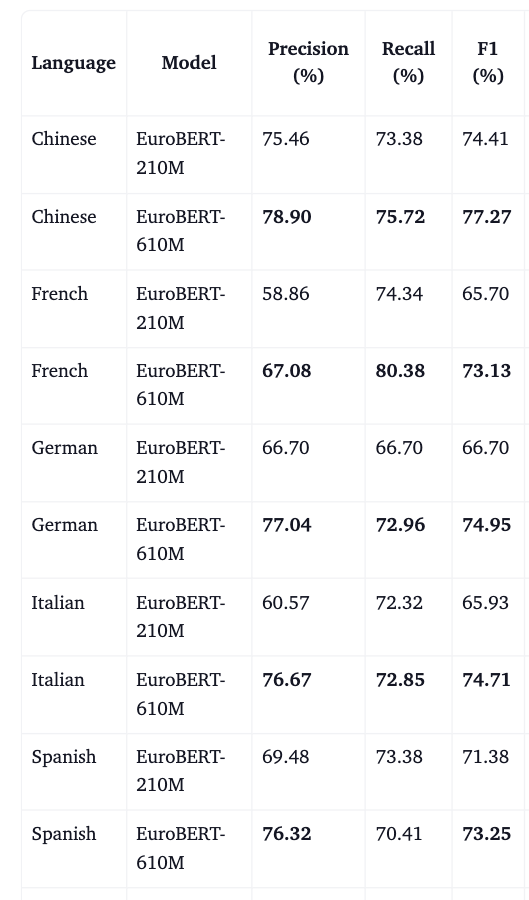

In [ ]:
gt_spans = []
pred_spans = []
task_types = []
languages = []

for batch in tqdm(iterator.gen_batches(1, data_type='test'), total=len(ds['test'])):
    x, y = batch
    prompt = x[0]['prompt']
    answer = x[0]['answer']
    task_types.append(x[0]['task_type'])
    gt_spans.append(x[0]['labels'])
    languages.append(x[0]['language'])

    encoding, _, offsets, answer_start_token = TorchTransformersHallucinationDetectorPreprocessor.prepare_tokenized_input(
            tokenizer, prompt, answer, max_seq_length
        )
    labels = torch.full_like(encoding.input_ids[0], -100, device=device)
    labels[answer_start_token:] = 0
    encoding = {
            key: value.to(device)
            for key, value in encoding.items()
            if key in ["input_ids", "attention_mask", "labels"]
        }
    with torch.inference_mode():
        outputs = main_model(**encoding)
    logits = outputs.logits
    token_preds = torch.argmax(logits, dim=-1)[0]
    probabilities = torch.softmax(logits, dim=-1)[0]
    token_preds = torch.where(labels == -100, labels, token_preds)

    if answer_start_token < offsets.size(0):
        answer_char_offset = offsets[answer_start_token][0].item()
    else:
        answer_char_offset = 0

    spans: list[dict] = []
    current_span: dict | None = None

    for i in range(answer_start_token, token_preds.size(0)):
        # Skip tokens marked as ignored.
        if labels[i].item() == -100:
            continue

        token_start, token_end = offsets[i].tolist()
        # Skip special tokens with zero length.
        if token_start == token_end:
            continue

        # Adjust offsets relative to the answer text.
        rel_start = token_start - answer_char_offset
        rel_end = token_end - answer_char_offset

        is_hallucination = (
            token_preds[i].item() == 1
        )  # assuming class 1 indicates hallucination.
        confidence = probabilities[i, 1].item() if is_hallucination else 0.0

        if is_hallucination:
            if current_span is None:
                current_span = {
                    "start": rel_start,
                    "end": rel_end,
                    "confidence": confidence,
                }
            else:
                # Extend the current span.
                current_span["end"] = rel_end
                current_span["confidence"] = max(current_span["confidence"], confidence)
        else:
            # If we were building a hallucination span, finalize it.
            if current_span is not None:
                # Extract the hallucinated text from the answer.
                span_text = answer[current_span["start"] : current_span["end"]]
                current_span["text"] = span_text
                spans.append(current_span)
                current_span = None

    # Append any span still in progress.
    if current_span is not None:
        span_text = answer[current_span["start"] : current_span["end"]]
        current_span["text"] = span_text
        spans.append(current_span)
    pred_spans.append(spans)


In [28]:
print('overall')
print(calc_span_level_metrics(df.pred_spans.values, df.gt_spans.values)['f1'])


overall
0.5432


In [26]:
lang

'chinese'

In [34]:
eng_df = df[df['language'] == 'en']

In [35]:
for task_type, subdf in eng_df.groupby('task_type'):
    print(task_type)
    
    print(calc_span_level_metrics(subdf.pred_spans.values, subdf.gt_spans.values))

print('overall')
print(calc_span_level_metrics(eng_df.pred_spans.values, eng_df.gt_spans.values))


Data2txt
{'precision': 0.5963, 'recall': 0.6183, 'f1': 0.6071}
QA
{'precision': 0.5904, 'recall': 0.6196, 'f1': 0.6047}
Summary
{'precision': 0.2058, 'recall': 0.5759, 'f1': 0.3032}
overall
{'precision': 0.5123, 'recall': 0.6151, 'f1': 0.559}


In [1]:
# 0 epochs mdeberta
# Data2txt
# {'precision': 0.5729, 'recall': 0.6261, 'f1': 0.5983}
# QA
# {'precision': 0.6057, 'recall': 0.6171, 'f1': 0.6114}
# Summary
# {'precision': 0.2233, 'recall': 0.6915, 'f1': 0.3376}
# overall
# {'precision': 0.5117, 'recall': 0.6275, 'f1': 0.5637}

In [28]:
for task_type, subdf in df.groupby('task_type'):
    print(task_type)
    print(calc_span_level_metrics(subdf.pred_spans.values, subdf.gt_spans.values))
print('overall')
print(calc_span_level_metrics(df.pred_spans.values, df.gt_spans.values))


Data2txt
{'precision': 0.5431, 'recall': 0.6387, 'f1': 0.587}
QA
{'precision': 0.6409, 'recall': 0.6007, 'f1': 0.6201}
Summary
{'precision': 0.2246, 'recall': 0.5999, 'f1': 0.3268}
overall
{'precision': 0.5124, 'recall': 0.617, 'f1': 0.5599}


In [49]:
## bellow precision and recall swapped.

In [ ]:
# 'KRLabsOrg/lettucedect-large-modernbert-en-v1'

# Data2txt
# {'precision': 0.5599, 'recall': 0.6471, 'f1': 0.6004}
# QA
# {'precision': 0.6214, 'recall': 0.6685, 'f1': 0.6441}
# Summary
# {'precision': 0.3547, 'recall': 0.6017, 'f1': 0.4463}
# overall
# {'precision': 0.5396, 'recall': 0.6492, 'f1': 0.5893}

In [25]:
# 'KRLabsOrg/lettucedect-base-modernbert-en-v1'
# Data2txt
# {'precision': 0.5657, 'recall': 0.5824, 'f1': 0.5739}
# QA
# {'precision': 0.604, 'recall': 0.6263, 'f1': 0.615}
# Summary
# {'precision': 0.2808, 'recall': 0.5298, 'f1': 0.3671}
# overall
# {'precision': 0.5201, 'recall': 0.5935, 'f1': 0.5544}

In [21]:
# Deberta small
# Data2txt
# {'precision': 0.568, 'recall': 0.6201, 'f1': 0.5929}
# QA
# {'precision': 0.6262, 'recall': 0.6152, 'f1': 0.6207}
# Summary
# {'precision': 0.3024, 'recall': 0.6173, 'f1': 0.406}
# overall
# {'precision': 0.5338, 'recall': 0.6177, 'f1': 0.5727}

In [18]:
# Modern Large
# Data2txt
# {'precision': 0.5302, 'recall': 0.6478, 'f1': 0.5831}
# QA
# {'precision': 0.6444, 'recall': 0.7358, 'f1': 0.6871}
# Summary
# {'precision': 0.3058, 'recall': 0.726, 'f1': 0.4304}
# overall
# {'precision': 0.5252, 'recall': 0.6945, 'f1': 0.5981}

In [29]:
# Modern Base
# Data2txt
# {'precision': 0.5682, 'recall': 0.5889, 'f1': 0.5784}
# QA
# {'precision': 0.5797, 'recall': 0.6819, 'f1': 0.6267}
# Summary
# {'precision': 0.2989, 'recall': 0.5389, 'f1': 0.3845}
# overall
# {'precision': 0.516, 'recall': 0.6168, 'f1': 0.5619}

In [62]:
# EuroBERT
# Data2txt
# {'precision': 0.5647749834546658, 'recall': 0.5762964630406033, 'f1': 0.5704775566480509}
# QA
# {'precision': 0.6283600025298842, 'recall': 0.6516035941496688, 'f1': 0.6397707514971989}
# Summary
# {'precision': 0.21977655494413872, 'recall': 0.41594782242794026, 'f1': 0.28759501036476703}
# overall
# {'precision': 0.515912293163478, 'recall': 0.5865182223751969, 'f1': 0.548954254844625}